# Финальный проект. Этап 3 — Анализ данных

**Цель этапа:** выявить закономерности и точки роста бизнеса: динамика во времени, эффективность каналов и кампаний, работа менеджеров, продукты и платежи, география продаж.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

---

## План этапа 3

| Раздел | Что анализируем | Таблица | Пункт ТЗ |
|---|---|---|---|
| **1** | Загрузка данных и подготовка дат | Deals, Calls, Spend | — |
| **2** | Временные ряды: динамика создания сделок (месяц/неделя, конверсия) | Deals | 3.3.1 |
| **3** | Динамика звонков и связь со сделками (звонков на сделку) | Calls + Deals | 3.3.1 |
| **4** | Время жизни сделки: от создания до закрытия | Deals | 3.3.2 |
| **5** | Кампании: объём лидов и конверсия | Deals | 3.4.1 |
| **6** | Источники трафика: качество лидов (доля A+B) | Deals | 3.4.2 |
| **7** | Отдел продаж: сделки, конверсия, выручка по менеджерам | Deals | 3.5.1 |
| **8.1** | Продукты: выручка и конверсия | Deals | 3.6.2 |
| **8.2** | Типы оплаты (Payment Type) и влияние на успешность | Deals | 3.6.1 |
| **8.3** | Типы обучения (Education Type): конверсия и средний чек | Deals | 3.6.2 |
| **8.4** | Причины потери сделок (Lost Reason) | Deals | 3.6 (доп.) |
| **9.1** | География: распределение сделок по городам | Deals | 3.7.1 ✱ |
| **9.2** | Уровень немецкого — исключён с обоснованием | Deals | 3.7.2 ✱ |
| **10** | Сводные бизнес-выводы и рекомендации | Deals | — |

> **Примечание по пункту 3.7.2 (✱).** ТЗ просит изучить влияние уровня немецкого на успешность сделок. Поле `Level of Deutsch` — несстандартизированный свободный текст менеджера (установлено на этапе 1): `B1`, `б1`, `В1`, `beginner` — одно и то же разными способами. Корректный анализ невозможен без нормализации в CRM. Решение и обоснование — в разделе 9.2.

## 1. Загрузка данных и подготовка дат

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [2]:
DATA_CLEAN = '../data_clean/'
PLOTS = '../data_clean/plots/'

deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False,
                    dtype={'Id': str, 'Contact Name': str})
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False,
                    dtype={'Id': str, 'CONTACTID': str})
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Загружено:')
print(f'  Deals:  {deals.shape}')
print(f'  Calls:  {calls.shape}')
print(f'  Spend:  {spend.shape}')


Загружено:
  Deals:  (21593, 26)
  Calls:  (95874, 9)
  Spend:  (19862, 8)


In [3]:
# CSV не хранит типы — восстанавливаем после загрузки
deals['Id']           = deals['Id'].astype(str)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], errors='coerce')
for col in ['Quality', 'Stage', 'Source', 'Product', 'Payment Type', 'Education Type', 'Lost Reason']:
    deals[col] = deals[col].astype('category')

calls['Id']              = calls['Id'].astype(str)
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])
for col in ['Call Type', 'Call Status', 'Outgoing Call Status']:
    calls[col] = calls[col].astype('category')

spend['Date']   = pd.to_datetime(spend['Date'])
spend['Source'] = spend['Source'].astype('category')

In [4]:
# Добавляем удобные временные признаки для группировки
deals['Created Month'] = deals['Created Time'].dt.to_period('M')
deals['Created Week']  = deals['Created Time'].dt.to_period('W')
deals['Created Day']   = deals['Created Time'].dt.date

calls['Call Month'] = calls['Call Start Time'].dt.to_period('M')

print('Типы дат после конвертации:')
print(f'  Created Time: {deals["Created Time"].dtype}')
print(f'  Call Start:   {calls["Call Start Time"].dtype}')
print(f'  Spend Date:   {spend["Date"].dtype}')


Типы дат после конвертации:
  Created Time: datetime64[ns]
  Call Start:   datetime64[ns]
  Spend Date:   datetime64[ns]


## 2. Временные ряды: динамика создания сделок

Смотрим, как менялся поток лидов со временем —
это позволяет увидеть сезонность, пики активности и провалы.


In [5]:
# Группируем по месяцам — агрегируем число сделок
monthly_deals = (
    deals.groupby('Created Month', observed=True)
    .size()
    .reset_index(name='Deals Count')
)

# Period → datetime для корректного отображения на графике
monthly_deals['Month'] = monthly_deals['Created Month'].dt.to_timestamp()

print('Сделок по месяцам:')
print(monthly_deals[['Month', 'Deals Count']].to_string(index=False))


Сделок по месяцам:
     Month  Deals Count
2023-07-01          654
2023-08-01         1085
2023-09-01         1079
2023-10-01         1598
2023-11-01         1947
2023-12-01         1811
2024-01-01         2243
2024-02-01         2184
2024-03-01         2252
2024-04-01         3082
2024-05-01         1984
2024-06-01         1674


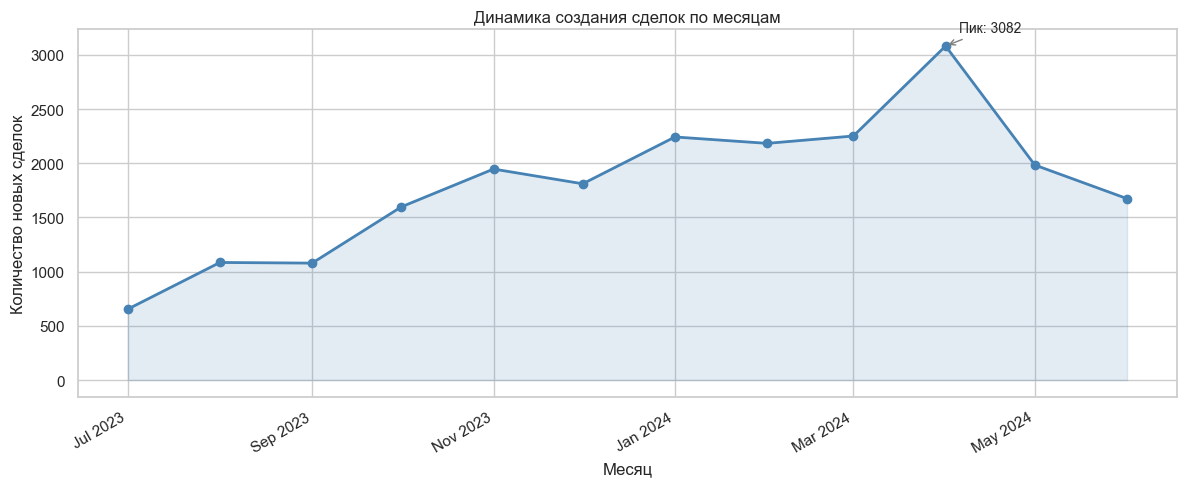

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_deals['Month'], monthly_deals['Deals Count'],
                alpha=0.15, color='steelblue')

ax.set_title('Динамика создания сделок по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество новых сделок')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

# Помечаем пик
peak_idx = monthly_deals['Deals Count'].idxmax()
peak_row = monthly_deals.loc[peak_idx]
ax.annotate(f'Пик: {peak_row["Deals Count"]}',
            xy=(peak_row['Month'], peak_row['Deals Count']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_monthly.png', dpi=100)
plt.show()


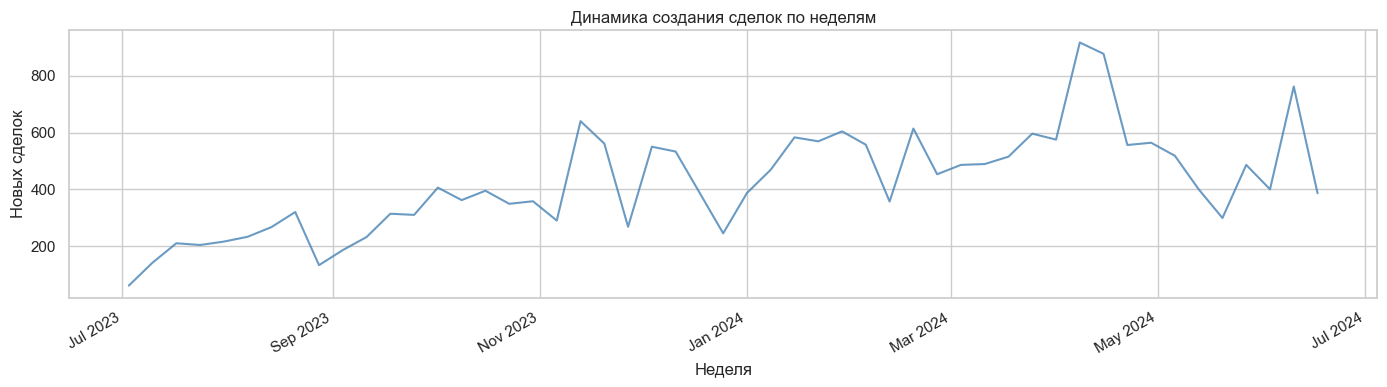

In [7]:
# Недельная динамика — видны краткосрочные колебания
weekly_deals = (
    deals.groupby('Created Week')
    .size()
    .reset_index(name='Deals Count')
)
weekly_deals['Week'] = weekly_deals['Created Week'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_deals['Week'], weekly_deals['Deals Count'],
        linewidth=1.5, color='steelblue', alpha=0.8)
ax.set_title('Динамика создания сделок по неделям')
ax.set_xlabel('Неделя')
ax.set_ylabel('Новых сделок')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_weekly.png', dpi=100)
plt.show()


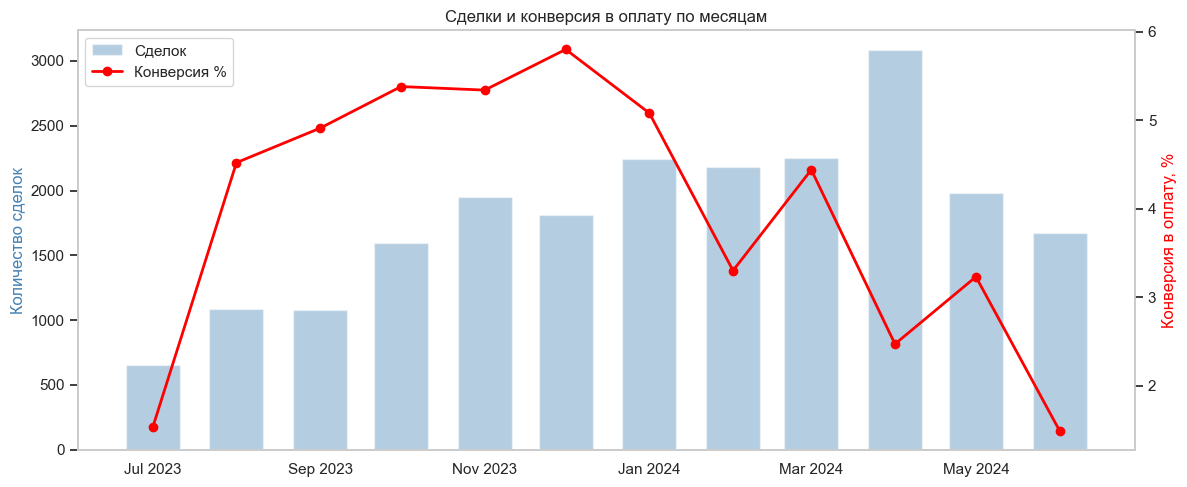

In [8]:
# Конверсия по месяцам — растёт ли качество со временем?
monthly_conv = deals.groupby('Created Month', observed=True).apply(
    lambda x: pd.Series({
        'Deals': len(x),
        'Paid': (x['Stage'] == 'Payment Done').sum(),
        'Conversion %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False
).reset_index()
monthly_conv['Month'] = monthly_conv['Created Month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Ось 1: число сделок (столбцы)
ax1.bar(monthly_conv['Month'], monthly_conv['Deals'],
        width=20, color='steelblue', alpha=0.4, label='Сделок')
ax1.set_ylabel('Количество сделок', color='steelblue')
ax1.grid(False)

# Ось 2: конверсия (линия)
ax2 = ax1.twinx()
ax2.plot(monthly_conv['Month'], monthly_conv['Conversion %'],
         color='red', marker='o', linewidth=2, label='Конверсия %')
ax2.set_ylabel('Конверсия в оплату, %', color='red')
ax2.grid(False)

ax1.set_title('Сделки и конверсия в оплату по месяцам')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_conversion_monthly.png', dpi=100)
plt.show()


In [9]:
# Выводим таблицу с лучшими и худшими месяцами по конверсии
print('Конверсия по месяцам (сортировка по убыванию):')
print(monthly_conv[['Month', 'Deals', 'Paid', 'Conversion %']]
      .sort_values('Conversion %', ascending=False)
      .to_string(index=False))


Конверсия по месяцам (сортировка по убыванию):
     Month  Deals  Paid  Conversion %
2023-12-01 1811.0 105.0          5.80
2023-10-01 1598.0  86.0          5.38
2023-11-01 1947.0 104.0          5.34
2024-01-01 2243.0 114.0          5.08
2023-09-01 1079.0  53.0          4.91
2023-08-01 1085.0  49.0          4.52
2024-03-01 2252.0 100.0          4.44
2024-02-01 2184.0  72.0          3.30
2024-05-01 1984.0  64.0          3.23
2024-04-01 3082.0  76.0          2.47
2023-07-01  654.0  10.0          1.53
2024-06-01 1674.0  25.0          1.49


**Вывод (раздел 2):** Пик по числу лидов — апрель 2024 (3 082 сделки). Лучшая конверсия в оплату — декабрь 2023 (5,80%), худшая — июнь 2024 (1,49%). Пики по объёму и качеству не совпадают: апрельский рост лидов сопровождался резким падением конверсии, что указывает на снижение качества трафика при масштабировании кампаний.

## 3. Динамика звонков и её связь со сделками

In [10]:
# Звонки по месяцам
monthly_calls = (
    calls.groupby('Call Month', observed=True)
    .size()
    .reset_index(name='Calls Count')
)
monthly_calls['Month'] = monthly_calls['Call Month'].dt.to_timestamp()

print('Звонки по месяцам:')
print(monthly_calls[['Month', 'Calls Count']].to_string(index=False))


Звонки по месяцам:
     Month  Calls Count
2023-06-01            7
2023-07-01         1935
2023-08-01         4251
2023-09-01         5156
2023-10-01         7102
2023-11-01         7170
2023-12-01         7099
2024-01-01         9804
2024-02-01         9599
2024-03-01        10081
2024-04-01        13328
2024-05-01        11847
2024-06-01         8495


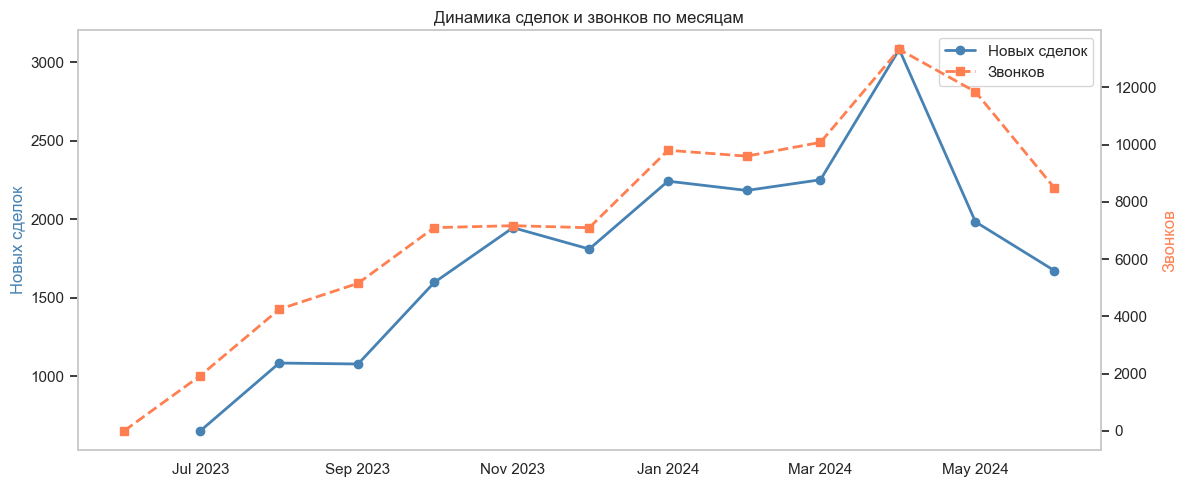

In [11]:
# Сравниваем динамику сделок и звонков на одном графике
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
         marker='o', linewidth=2, color='steelblue', label='Новых сделок')
ax1.set_ylabel('Новых сделок', color='steelblue')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(monthly_calls['Month'], monthly_calls['Calls Count'],
         marker='s', linewidth=2, color='coral', linestyle='--', label='Звонков')
ax2.set_ylabel('Звонков', color='coral')
ax2.grid(False)

ax1.set_title('Динамика сделок и звонков по месяцам')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_vs_calls.png', dpi=100)
plt.show()


In [12]:
# Среднее число звонков на сделку по месяцам
merged = pd.merge(
    monthly_deals[['Month', 'Deals Count']],
    monthly_calls[['Month', 'Calls Count']],
    on='Month', how='inner'
)
merged['Calls per Deal'] = (merged['Calls Count'] / merged['Deals Count']).round(1)
print('Звонков на одну сделку по месяцам:')
print(merged[['Month', 'Deals Count', 'Calls Count', 'Calls per Deal']].to_string(index=False))


Звонков на одну сделку по месяцам:
     Month  Deals Count  Calls Count  Calls per Deal
2023-07-01          654         1935             3.0
2023-08-01         1085         4251             3.9
2023-09-01         1079         5156             4.8
2023-10-01         1598         7102             4.4
2023-11-01         1947         7170             3.7
2023-12-01         1811         7099             3.9
2024-01-01         2243         9804             4.4
2024-02-01         2184         9599             4.4
2024-03-01         2252        10081             4.5
2024-04-01         3082        13328             4.3
2024-05-01         1984        11847             6.0
2024-06-01         1674         8495             5.1


**Вывод (раздел 3):** Динамика звонков повторяет динамику сделок с небольшим отставанием — менеджеры обрабатывают входящий поток. Среднее число звонков на сделку варьируется от 3,0 (июль 2023) до 6,0 (май 2024). Рост нагрузки в мае 2024 — тревожный сигнал: при меньшем числе новых сделок звонков потребовалось значительно больше, что снижает эффективность отдела продаж.

## 4. Время жизни сделки: от создания до закрытия

Анализируем, сколько дней проходит от создания сделки до её закрытия.
Сравниваем Payment Done (успешные) и Lost (проигранные).


In [13]:
# Вычисляем время жизни сделки в днях
# Используем только строки без ошибки в Closing Date
closed = deals[
    deals['Closing Date'].notna() & (deals['closing_date_error'] == False)
].copy()

closed['Days to Close'] = (
    closed['Closing Date'] - closed['Created Time']
).dt.days

print(f'Закрытых сделок (без ошибок в дате): {len(closed)}')
print()
print('Время жизни сделки (в днях):')
print(closed.groupby('Stage')['Days to Close']
      .describe().round(1)
      .to_string())


Закрытых сделок (без ошибок в дате): 14601

Время жизни сделки (в днях):
                             count  mean   std  min  25%   50%   75%    max
Stage                                                                      
Call Delayed                 228.0  23.6  45.0 -1.0  0.0   3.0  27.2  287.0
Free Education                 0.0   NaN   NaN  NaN  NaN   NaN   NaN    NaN
Lost                       13818.0  13.2  30.5 -1.0  0.0   2.0  10.0  334.0
Need To Call                   0.0   NaN   NaN  NaN  NaN   NaN   NaN    NaN
Need a consultation            0.0   NaN   NaN  NaN  NaN   NaN   NaN    NaN
Need to Call - Sales           2.0   3.0   1.4  2.0  2.5   3.0   3.5    4.0
New Lead                       0.0   NaN   NaN  NaN  NaN   NaN   NaN    NaN
Payment Done                 517.0  32.5  43.0 -1.0  6.0  16.0  42.0  304.0
Qualificated                   2.0   1.0   1.4  0.0  0.5   1.0   1.5    2.0
Registered on Offline Day      0.0   NaN   NaN  NaN  NaN   NaN   NaN    NaN
Registered on W

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_43048\220670135.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(closed.groupby('Stage')['Days to Close']


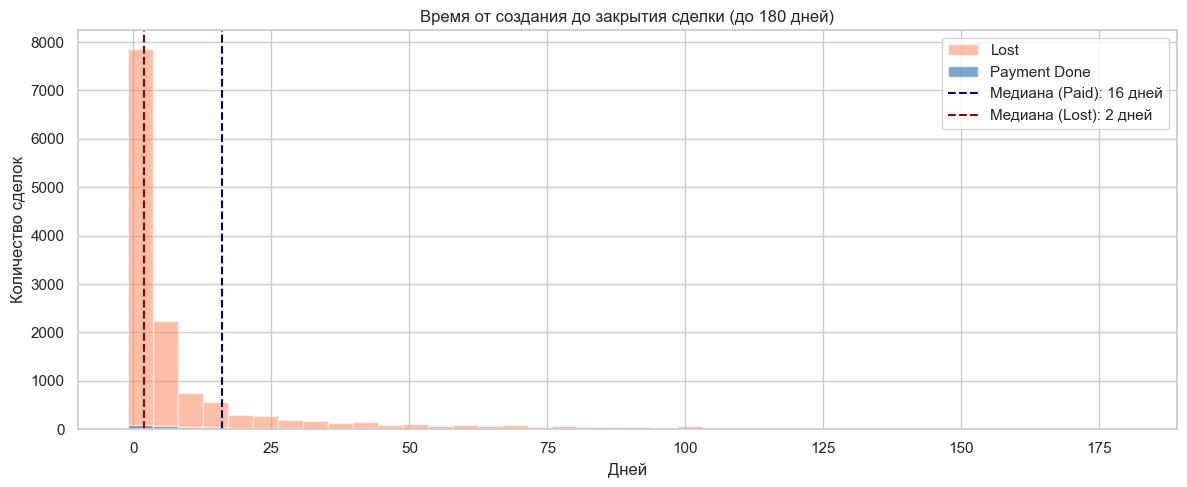

In [14]:
# Сравниваем распределение для Payment Done и Lost
paid_days = closed.loc[closed['Stage'] == 'Payment Done', 'Days to Close'].dropna()
lost_days = closed.loc[closed['Stage'] == 'Lost', 'Days to Close'].dropna()

# Ограничиваем до 180 дней — убираем крайние выбросы
paid_trimmed = paid_days[paid_days <= 180]
lost_trimmed = lost_days[lost_days <= 180]

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(lost_trimmed, bins=40, alpha=0.5, color='coral', label='Lost')
ax.hist(paid_trimmed, bins=40, alpha=0.7, color='steelblue', label='Payment Done')

ax.axvline(paid_trimmed.median(), color='navy', linestyle='--',
           label=f'Медиана (Paid): {paid_trimmed.median():.0f} дней')
ax.axvline(lost_trimmed.median(), color='darkred', linestyle='--',
           label=f'Медиана (Lost): {lost_trimmed.median():.0f} дней')

ax.set_title('Время от создания до закрытия сделки (до 180 дней)')
ax.set_xlabel('Дней')
ax.set_ylabel('Количество сделок')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'deal_lifecycle.png', dpi=100)
plt.show()


In [15]:
print(f'Медиана дней до оплаты (до 180 дней): {paid_trimmed.median():.0f}')
print(f'Медиана дней до потери (до 180 дней):  {lost_trimmed.median():.0f}')


Медиана дней до оплаты (до 180 дней): 16
Медиана дней до потери (до 180 дней):  2


**Вывод (раздел 4):** Медиана времени до оплаты — 16 дней, медиана до потери — 2 дня. Потерянные сделки закрываются очень быстро: клиент либо перестаёт отвечать сразу, либо быстро отказывается. Успешные оплаты требуют в среднем двух недель — это рабочий цикл принятия решения. Это подтверждает гипотезу: если клиент не заплатил за 30+ дней, вероятность оплаты резко снижается.

## 5. Анализ маркетинговых кампаний

Оцениваем эффективность кампаний: сколько лидов привлекают
и какой процент из них конвертируется в оплату.


In [16]:
# Оставляем только сделки с заполненной кампанией
with_campaign = deals[deals['Campaign'].notna()].copy()
print(f'Сделок с кампанией: {len(with_campaign)} из {len(deals)}')


Сделок с кампанией: 16067 из 21593


In [17]:
# Сколько всего уникальных кампаний?
total_campaigns = with_campaign['Campaign'].nunique()
print(f'Всего уникальных кампаний: {total_campaigns}')
print(f'Показываем топ-20 по количеству лидов')

Всего уникальных кампаний: 154
Показываем топ-20 по количеству лидов


In [18]:
# Агрегируем по кампаниям
campaign_stats = (
    with_campaign.groupby('Campaign', observed=True)
    .apply(lambda x: pd.Series({
        'Лидов': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False)
    .reset_index()
    .sort_values('Лидов', ascending=False)
)

# Сколько уникальных кампаний? Берём топ-20 по объёму — это ~80% всего трафика
n_campaigns = len(campaign_stats)
top20_share = campaign_stats.head(20)['Лидов'].sum() / campaign_stats['Лидов'].sum() * 100
print(f'Всего уникальных кампаний: {n_campaigns}')
print(f'Топ-20 охватывают {top20_share:.1f}% всех лидов с кампанией')
print()
print('Топ-20 кампаний по числу лидов:')
print(campaign_stats.head(20).to_string(index=False))


Всего уникальных кампаний: 154
Топ-20 охватывают 80.4% всех лидов с кампанией

Топ-20 кампаний по числу лидов:
                         Campaign  Лидов  Оплат  Конверсия %
performancemax_digitalmarkt_ru_DE 2653.0  112.0         4.22
                youtube_shorts_DE 1635.0   53.0         3.24
                12.07.2023wide_DE 1575.0   48.0         3.05
                  02.07.23wide_DE  975.0   52.0         5.33
         04.07.23recentlymoved_DE  750.0   31.0         4.13
                    03.07.23women  612.0   31.0         5.07
                           Dis_DE  581.0   30.0         5.16
                   07.07.23LAL_DE  542.0   28.0         5.17
        12.09.23interests_Uxui_DE  531.0   27.0         5.08
           24.09.23retargeting_DE  479.0   17.0         3.55
                      webinar1604  343.0    3.0         0.87
                          work_DE  317.0   10.0         3.15
                      webinar1906  290.0    0.0         0.00
          08.04.24wide_webinar_DE  

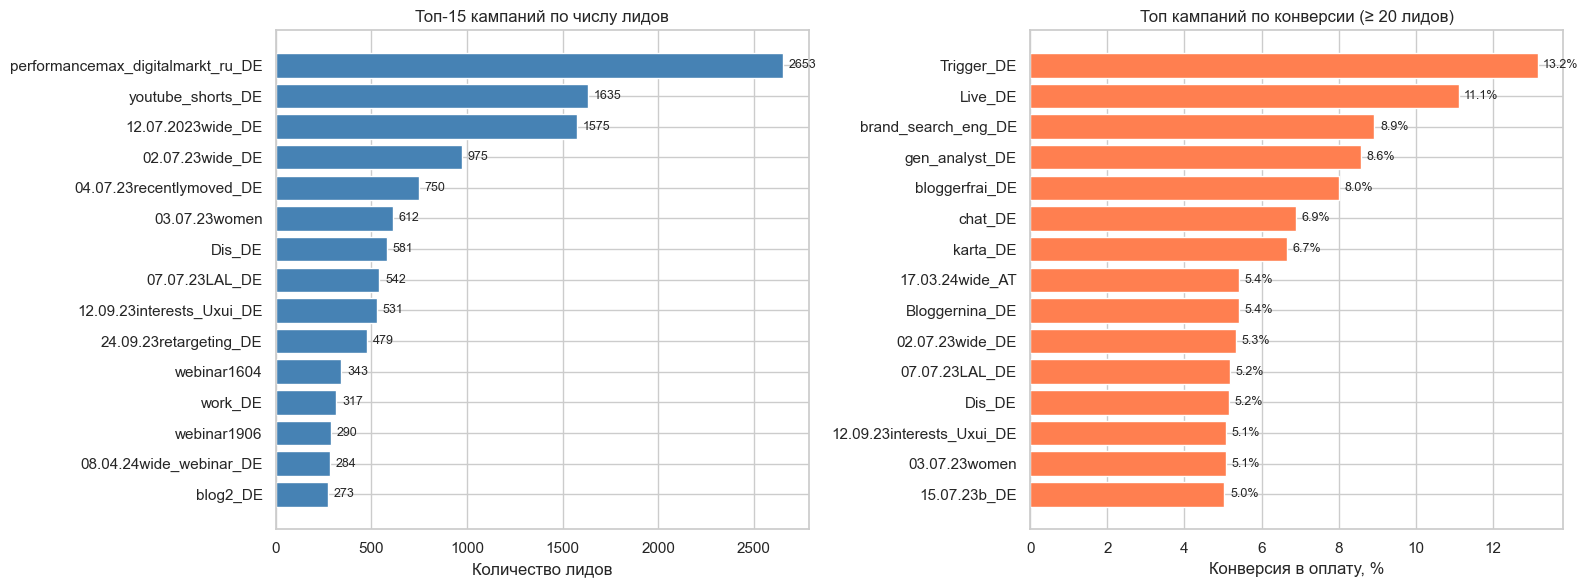

In [19]:
# Топ-15 кампаний по числу лидов — визуализация
top15_campaigns = campaign_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый: лиды по кампаниям
bars = axes[0].barh(top15_campaigns['Campaign'][::-1],
                    top15_campaigns['Лидов'][::-1], color='steelblue')
axes[0].set_title('Топ-15 кампаний по числу лидов')
axes[0].set_xlabel('Количество лидов')
axes[0].bar_label(bars, fmt='%d', padding=4, fontsize=9)

# Правый: конверсия (только кампании с ≥ 20 лидами)
conv_campaigns = campaign_stats[campaign_stats['Лидов'] >= 20].sort_values(
    'Конверсия %', ascending=False).head(15)

bars2 = axes[1].barh(conv_campaigns['Campaign'][::-1],
                     conv_campaigns['Конверсия %'][::-1], color='coral')
axes[1].set_title('Топ кампаний по конверсии (≥ 20 лидов)')
axes[1].set_xlabel('Конверсия в оплату, %')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS + 'campaign_analysis.png', dpi=100)
plt.show()


In [20]:
# Кампании с достаточным числом лидов для оценки конверсии (≥ 20 лидов)
eligible = campaign_stats[campaign_stats['Лидов'] >= 20]
print(f'Кампаний с ≥ 20 лидами: {len(eligible)}')
print(f'Показываем топ-10 по конверсии')

Кампаний с ≥ 20 лидами: 64
Показываем топ-10 по конверсии


In [21]:
# Лучшие кампании по конверсии (минимум 20 лидов)
top_conv = campaign_stats[campaign_stats['Лидов'] >= 20].sort_values(
    'Конверсия %', ascending=False).head(10)
print('Лучшие кампании по конверсии (≥ 20 лидов):')
print(top_conv.to_string(index=False))


Лучшие кампании по конверсии (≥ 20 лидов):
           Campaign  Лидов  Оплат  Конверсия %
         Trigger_DE   38.0    5.0        13.16
            Live_DE   27.0    3.0        11.11
brand_search_eng_DE  168.0   15.0         8.93
     gen_analyst_DE   35.0    3.0         8.57
     bloggerfrai_DE   25.0    2.0         8.00
            chat_DE   29.0    2.0         6.90
           karta_DE   30.0    2.0         6.67
    17.03.24wide_AT   37.0    2.0         5.41
     Bloggernina_DE   37.0    2.0         5.41
    02.07.23wide_DE  975.0   52.0         5.33


**Вывод (раздел 5):** Всего 154 уникальные кампании. Крупнейшая по объёму — `performancemax_digitalmarkt_ru_DE` (2 653 лида, конверсия 4,22%). Лучшая по конверсии среди кампаний с ≥ 20 лидами — `Trigger_DE` (13,16%) и `Live_DE` (11,11%) — оба формата аудитории с сильным намерением. Брендовая поисковая кампания `brand_search_eng_DE` (8,93%) подтверждает: чем «теплее» трафик, тем выше конверсия. Эти кампании стоит масштабировать.

## 6. Источники трафика: качество лидов

Смотрим, какие источники приносят «горячих» лидов (Quality A/B),
а какие — нецелевой трафик (D/E). Это ключ к оптимизации бюджета.


In [22]:
# Разделяем лиды на «качественные» и «нецелевые»
quality_map = {
    'A - High': 'Качественные (A+B)',
    'B - Medium': 'Качественные (A+B)',
    'C - Low': 'Средние (C)',
    'D - Non Target': 'Нецелевые (D+E)',
    'E - Non Qualified': 'Нецелевые (D+E)'
}
deals['Quality Group'] = deals['Quality'].map(quality_map)

# Доля по группам качества для каждого источника
source_quality = (
    deals[deals['Quality'].notna() & deals['Source'].notna()]
    .groupby(['Source', 'Quality Group'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Добавляем % качественных лидов
if 'Качественные (A+B)' in source_quality.columns:
    source_quality['% качественных'] = (
        source_quality['Качественные (A+B)'] /
        source_quality.sum(axis=1) * 100
    ).round(1)

source_quality['Всего'] = source_quality.sum(axis=1)
source_quality = source_quality.sort_values('Всего', ascending=False)
print(source_quality.to_string())


Quality Group   Качественные (A+B)  Нецелевые (D+E)  Средние (C)  % качественных   Всего
Source                                                                                  
Facebook Ads                   584             2998          896            13.0  4491.0
Google Ads                     405             3104          692             9.6  4210.6
Organic                        276             1829          318            11.4  2434.4
Tiktok Ads                     121             1325          354             6.7  1806.7
Youtube Ads                    129             1213          301             7.9  1650.9
SMM                            165             1041          344            10.6  1560.6
Telegram posts                 108              699          186            10.9  1003.9
Bloggers                       105              685          200            10.6  1000.6
CRM                             40              553           96             5.8   694.8
Webinar              

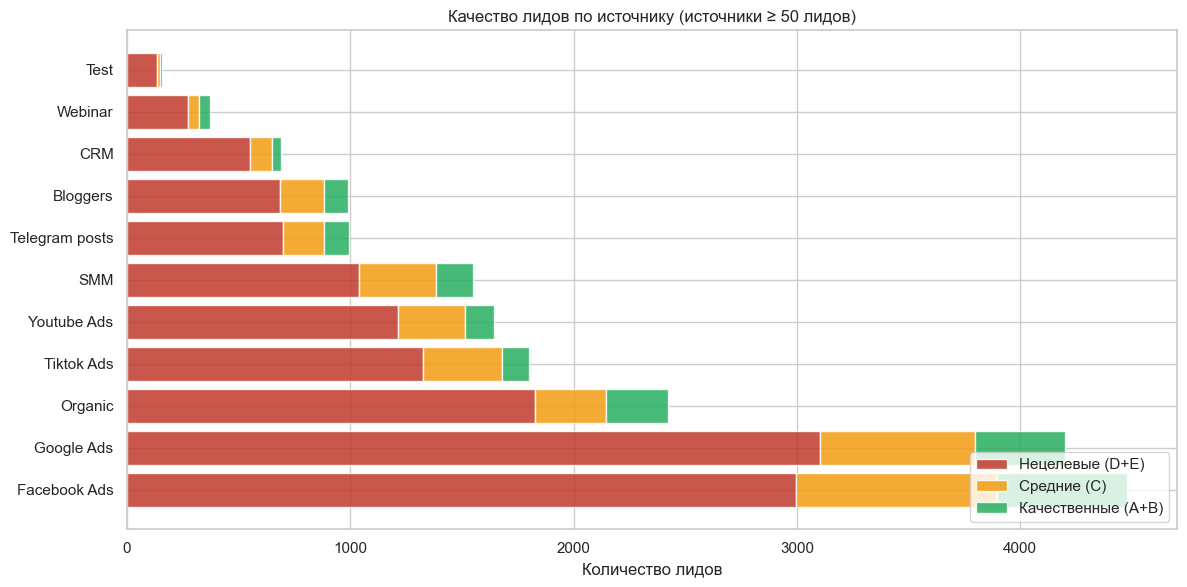

In [23]:
# Визуализация: стекированный барчарт по источникам
sq_plot = source_quality.drop(columns=['Всего', '% качественных'],
                               errors='ignore')
sq_plot = sq_plot[sq_plot.sum(axis=1) >= 50]  # только крупные источники

colors_stack = {'Качественные (A+B)': '#27ae60',
                'Средние (C)': '#f39c12',
                'Нецелевые (D+E)': '#c0392b'}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(sq_plot))

for col in ['Нецелевые (D+E)', 'Средние (C)', 'Качественные (A+B)']:
    if col in sq_plot.columns:
        values = sq_plot[col].values
        ax.barh(sq_plot.index, values, left=bottom,
                color=colors_stack.get(col, 'gray'), label=col, alpha=0.85)
        bottom += values

ax.set_title('Качество лидов по источнику (источники ≥ 50 лидов)')
ax.set_xlabel('Количество лидов')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PLOTS + 'source_quality_breakdown.png', dpi=100)
plt.show()


In [24]:
# Рейтинг источников по % качественных лидов
if '% качественных' in source_quality.columns:
    quality_rank = (source_quality[source_quality['Всего'] >= 50]
                    ['% качественных']
                    .sort_values(ascending=False))
    print('% качественных лидов (A+B) по источнику (≥ 50 лидов):')
    print(quality_rank.to_string())


% качественных лидов (A+B) по источнику (≥ 50 лидов):
Source
Partnership       16.2
Facebook Ads      13.0
Webinar           12.9
Organic           11.4
Telegram posts    10.9
SMM               10.6
Bloggers          10.6
Google Ads         9.6
Youtube Ads        7.9
Tiktok Ads         6.7
CRM                5.8
Test               5.7


**Вывод (раздел 6):** Лучшее качество лидов (доля A+B) — у Partnership (16,2%), Facebook Ads (13,0%) и Webinar (12,9%). Google Ads при самом высоком бюджете (57 799 €) даёт лишь 9,6% качественных лидов — значительно хуже органики (11,4%) и вебинаров. TikTok Ads и CRM — наименее эффективны по качеству (6,7% и 5,8% соответственно). Оптимизация микса в сторону органики, вебинаров и Facebook снизит долю нецелевого трафика.

## 7. Анализ отдела продаж (менеджеры)

Оцениваем каждого менеджера по трём критериям:
количество сделок, конверсия в оплату и суммарная выручка.


In [25]:
# Убираем строки без менеджера
with_owner = deals[deals['Deal Owner Name'].notna()].copy()

# Агрегируем по менеджерам
manager_stats = (
    with_owner.groupby('Deal Owner Name', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2),
        'Выручка': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()
            & (~x['Initial Amount Paid'].isin([0, 1, 9])),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
    .sort_values('Конверсия %', ascending=False)
)

print('Статистика менеджеров (сортировка по конверсии):')
print(manager_stats.to_string(index=False))


Статистика менеджеров (сортировка по конверсии):
Deal Owner Name  Сделок  Оплат  Конверсия %  Выручка
  Oliver Taylor   163.0   50.0        30.67  50250.0
   Kevin Parker   574.0   40.0         6.97  23950.0
  Ulysses Adams  2165.0  141.0         6.51 127100.0
       John Doe    20.0    1.0         5.00      0.0
  Charlie Davis  2963.0  148.0         4.99 141750.0
Paula Underwood  1862.0   93.0         4.99 101650.0
   Julia Nelson  2241.0   93.0         4.15  85050.0
       Eva Kent   459.0   18.0         3.92  20100.0
     Nina Scott  1283.0   46.0         3.59  40700.0
  Victor Barnes  1232.0   44.0         3.57  66700.0
 Quincy Vincent  1884.0   65.0         3.45  72400.0
       Ben Hall  1345.0   46.0         3.42  58700.0
     Jane Smith   988.0   31.0         3.14  27200.0
   Cara Iverson  1056.0   27.0         2.56 151900.0
    George King    94.0    2.0         2.13    900.0
     Ian Miller   497.0    8.0         1.61   8050.0
  Mason Roberts   268.0    3.0         1.12   1900

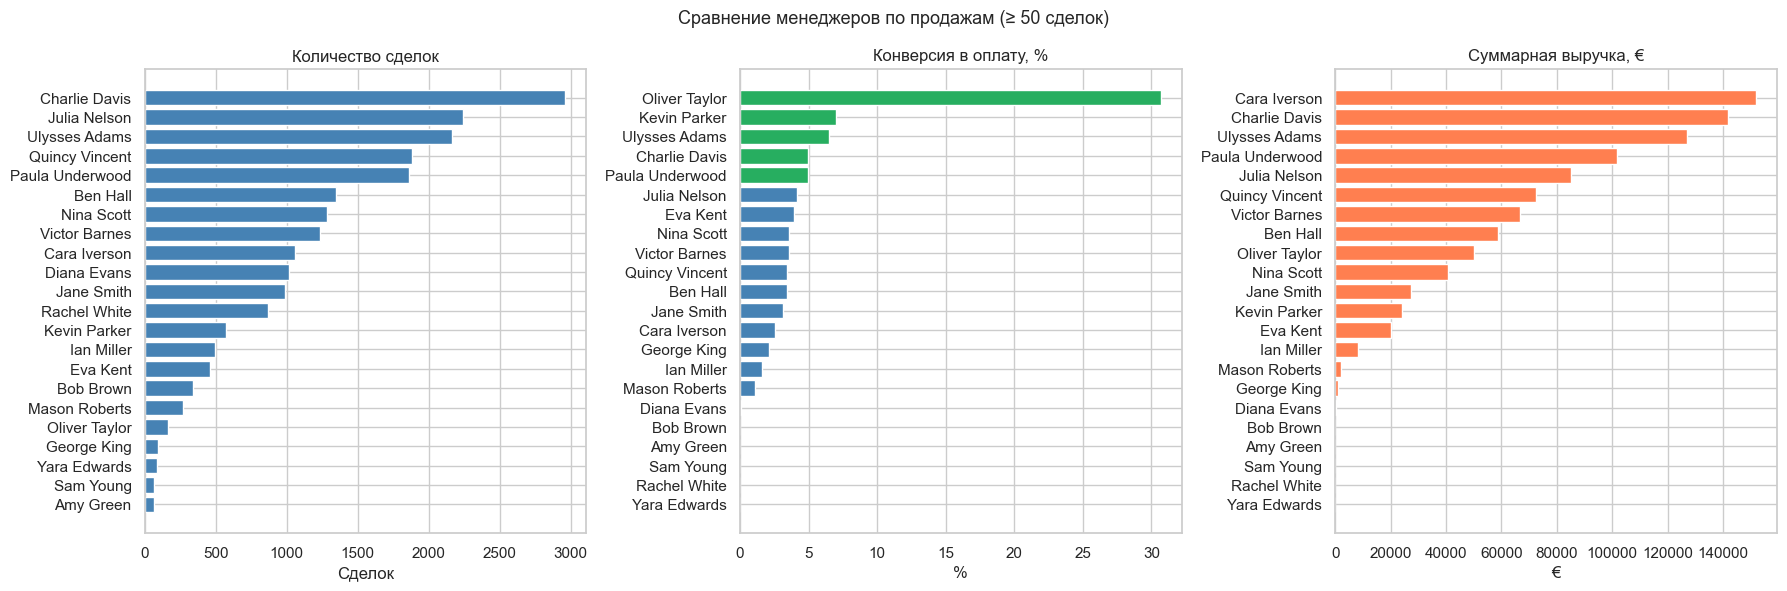

In [26]:
# Топ и антитоп по конверсии — только менеджеры с ≥ 50 сделок
active_managers = manager_stats[manager_stats['Сделок'] >= 50].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: число сделок
sorted_by_deals = active_managers.sort_values('Сделок', ascending=False)
axes[0].barh(sorted_by_deals['Deal Owner Name'][::-1],
             sorted_by_deals['Сделок'][::-1], color='steelblue')
axes[0].set_title('Количество сделок')
axes[0].set_xlabel('Сделок')

# График 2: конверсия
sorted_by_conv = active_managers.sort_values('Конверсия %', ascending=False)
colors_conv = ['#27ae60' if i < 5 else ('#c0392b' if i >= len(sorted_by_conv) - 3
               else 'steelblue')
               for i in range(len(sorted_by_conv))]
axes[1].barh(sorted_by_conv['Deal Owner Name'][::-1],
             sorted_by_conv['Конверсия %'][::-1],
             color=colors_conv[::-1])
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_xlabel('%')

# График 3: выручка
sorted_by_rev = active_managers.sort_values('Выручка', ascending=False)
axes[2].barh(sorted_by_rev['Deal Owner Name'][::-1],
             sorted_by_rev['Выручка'][::-1], color='coral')
axes[2].set_title('Суммарная выручка, €')
axes[2].set_xlabel('€')

plt.suptitle('Сравнение менеджеров по продажам (≥ 50 сделок)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'manager_comparison.png', dpi=100)
plt.show()


In [27]:
# Топ-3 и антитоп-3 по конверсии
top3 = active_managers.nlargest(3, 'Конверсия %')
bot3 = active_managers.nsmallest(3, 'Конверсия %')

print('ТОП-3 менеджера по конверсии:')
print(top3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))
print()
print('АНТИТОП-3 менеджера по конверсии:')
print(bot3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))


ТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
  Oliver Taylor   163.0   50.0        30.67
   Kevin Parker   574.0   40.0         6.97
  Ulysses Adams  2165.0  141.0         6.51

АНТИТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
      Bob Brown   337.0    0.0          0.0
      Amy Green    66.0    0.0          0.0
      Sam Young    67.0    0.0          0.0


In [28]:
# Разброс конверсии — есть ли значимые различия между менеджерами?
conv_std = active_managers['Конверсия %'].std()
conv_mean = active_managers['Конверсия %'].mean()
print(f'Средняя конверсия по активным менеджерам (≥ 50 сделок): {conv_mean:.2f}%')
print(f'Стандартное отклонение:                                   {conv_std:.2f}%')


Средняя конверсия по активным менеджерам (≥ 50 сделок): 3.95%
Стандартное отклонение:                                   6.34%


**Вывод (раздел 7):** Разброс конверсии среди активных менеджеров огромный: средняя — 3,95%, стандартное отклонение — 6,34%. Лидер — Oliver Taylor (30,67%), что в 7,5 раз выше среднего. Три менеджера (Bob Brown, Amy Green, Sam Young) с нулевой конверсией при 66–337 сделках — критичная зона. Cara Iverson при конверсии 2,56% обеспечивает наибольшую выручку (151 900 €) за счёт высокого среднего чека. Такой разброс указывает на огромный потенциал роста через обмен практиками и пересмотр распределения лидов.

## 8. Продукты и платежи

### 8.1 Выручка и конверсия по продуктам

In [29]:
# Анализируем только сделки с заполненным продуктом
with_product = deals[deals['Product'].notna()].copy()
n_products = deals['Product'].nunique()
print(f'Всего уникальных продуктов: {n_products}')
print()

product_stats = (
    with_product.groupby('Product', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2),
        'Средний чек': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()
            & (~x['Initial Amount Paid'].isin([0, 1, 9])),
            'Initial Amount Paid'
        ].median()
    }), include_groups=False)
    .reset_index()
    .sort_values('Оплат', ascending=False)
)

print('Статистика по всем продуктам:')
print(product_stats.to_string(index=False))


Всего уникальных продуктов: 5

Статистика по всем продуктам:
            Product  Сделок  Оплат  Конверсия %  Средний чек
  Digital Marketing  1990.0  474.0        23.82       1000.0
       UX/UI Design  1022.0  229.0        22.41       1000.0
      Web Developer   575.0  137.0        23.83       1000.0
Find yourself in IT     4.0    1.0        25.00          NaN
     Data Analytics     1.0    0.0         0.00          NaN


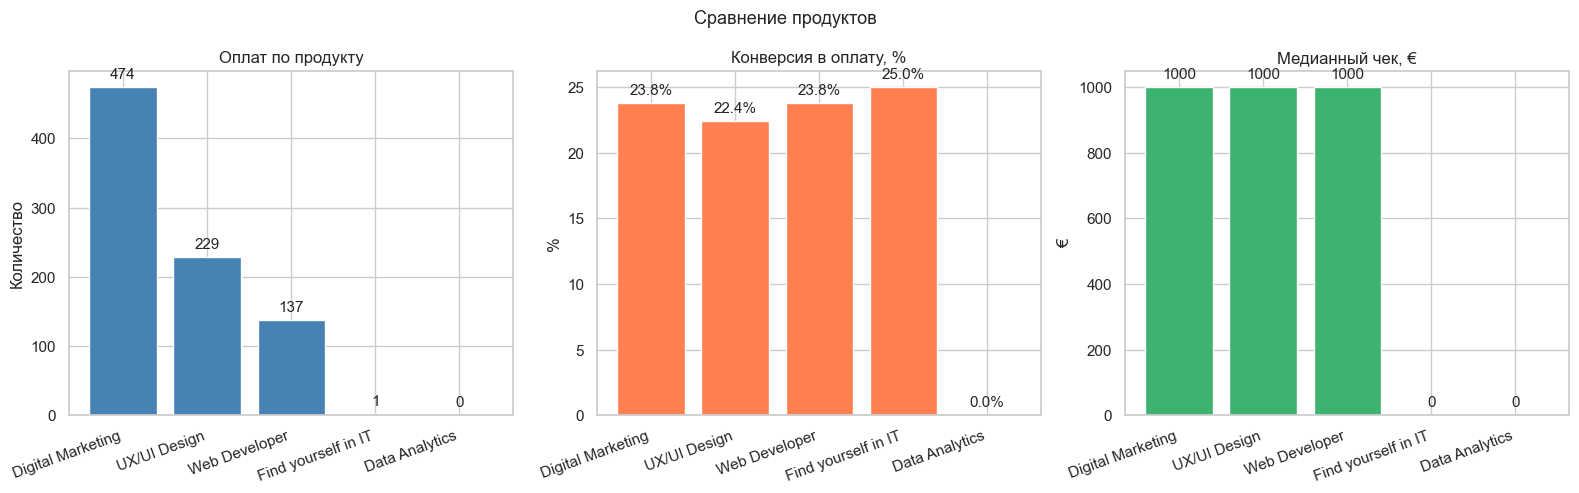

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Число оплат по продукту
bars0 = axes[0].bar(product_stats['Product'], product_stats['Оплат'],
                    color='steelblue')
axes[0].set_title('Оплат по продукту')
axes[0].set_ylabel('Количество')
axes[0].bar_label(bars0, fmt='%d', padding=4)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Конверсия по продукту
bars1 = axes[1].bar(product_stats['Product'], product_stats['Конверсия %'],
                    color='coral')
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_ylabel('%')
axes[1].bar_label(bars1, fmt='%.1f%%', padding=4)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Средний чек по продукту
bars2 = axes[2].bar(product_stats['Product'],
                    product_stats['Средний чек'].fillna(0),
                    color='mediumseagreen')
axes[2].set_title('Медианный чек, €')
axes[2].set_ylabel('€')
axes[2].bar_label(bars2, fmt='%.0f', padding=4)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.suptitle('Сравнение продуктов', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'product_comparison.png', dpi=100)
plt.show()


**Вывод (раздел 8.1):** Всего 5 продуктов. Три основных — Digital Marketing (474 оплаты), UX/UI Design (229), Web Developer (137) — с одинаковым медианным чеком 1 000 €. Конверсия у всех трёх практически одинакова (~22–24%), что говорит об одинаковой «горячести» аудитории, а не о преимуществах конкретного продукта. Data Analytics и Find yourself in IT — единичные наблюдения, выводы по ним нерепрезентативны.

### 8.2 Типы оплаты (Payment Type)

In [31]:
# Payment Type заполняется на стадии оформления оплаты — смотрим распределение и конверсию
pt = deals[deals['Payment Type'].notna()].copy()
print(f'Payment Type заполнен у {len(pt)} из {len(deals)} сделок ({len(pt)/len(deals)*100:.1f}%)')
print(f'Уникальных типов оплаты: {pt["Payment Type"].nunique()}')
print()

payment_stats = (
    pt.groupby('Payment Type', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False)
    .sort_values('Сделок', ascending=False)
    .reset_index()
)
print('Конверсия в оплату по типу оплаты:')
print(payment_stats.to_string(index=False))

Payment Type заполнен у 496 из 21593 сделок (2.3%)
Уникальных типов оплаты: 3

Конверсия в оплату по типу оплаты:
      Payment Type  Сделок  Оплат  Конверсия %
Recurring Payments   350.0  250.0        71.43
       One Payment   141.0  113.0        80.14
       Reservation     5.0    1.0        20.00


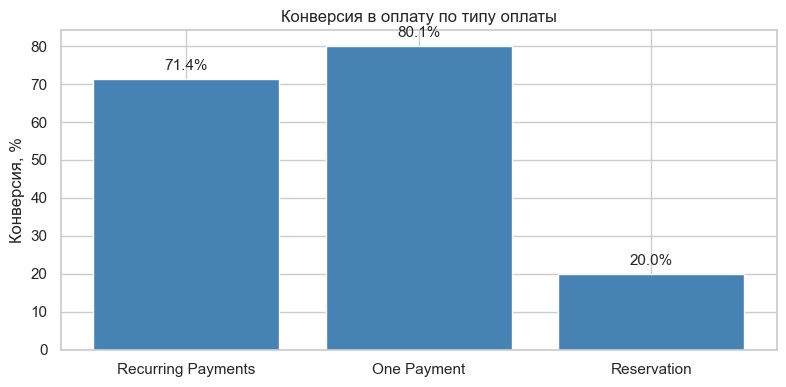

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(payment_stats['Payment Type'], payment_stats['Конверсия %'],
              color='steelblue')
ax.set_title('Конверсия в оплату по типу оплаты')
ax.set_ylabel('Конверсия, %')
ax.bar_label(bars, fmt='%.1f%%', padding=4)

plt.tight_layout()
plt.savefig(PLOTS + 'payment_type_conversion.png', dpi=100)
plt.show()

**Вывод (раздел 8.2):** Поле `Payment Type` заполнено лишь у 496 сделок (2,3%) — оно фиксируется на стадии оформления оплаты, поэтому конверсия по нему высокая у всех типов и отражает не «влияние способа оплаты на успех», а позднюю стадию воронки. Среди заполненных: One Payment (единовременно) — 80,1%, Recurring Payments (рассрочка) — 71,4%, Reservation (бронь) — 20% (всего 5 сделок, нерепрезентативно). Вывод: тип оплаты — не предиктор успеха на входе. Рассрочка преобладает по объёму (350 сделок), что важно для финансового планирования — выручка поступает частями, а не единовременно.

### 8.3 Типы обучения (Education Type)

In [33]:
# Education Type — формат обучения. Смотрим распределение, конверсию и средний чек
et = deals[deals['Education Type'].notna()].copy()
print(f'Education Type заполнен у {len(et)} из {len(deals)} сделок ({len(et)/len(deals)*100:.1f}%)')
print(f'Уникальных типов обучения: {et["Education Type"].nunique()}')
print()

edu_stats = (
    et.groupby('Education Type', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2),
        'Медиана чека': x.loc[(x['Stage'] == 'Payment Done')
                              & x['Initial Amount Paid'].notna(), 'Initial Amount Paid'].median()
    }), include_groups=False)
    .sort_values('Сделок', ascending=False)
    .reset_index()
)
print('Конверсия и средний чек по типу обучения:')
print(edu_stats.to_string(index=False))

Education Type заполнен у 3299 из 21593 сделок (15.3%)
Уникальных типов обучения: 2

Конверсия и средний чек по типу обучения:
Education Type  Сделок  Оплат  Конверсия %  Медиана чека
       Morning  2895.0  662.0        22.87        1000.0
       Evening   404.0  171.0        42.33         350.0


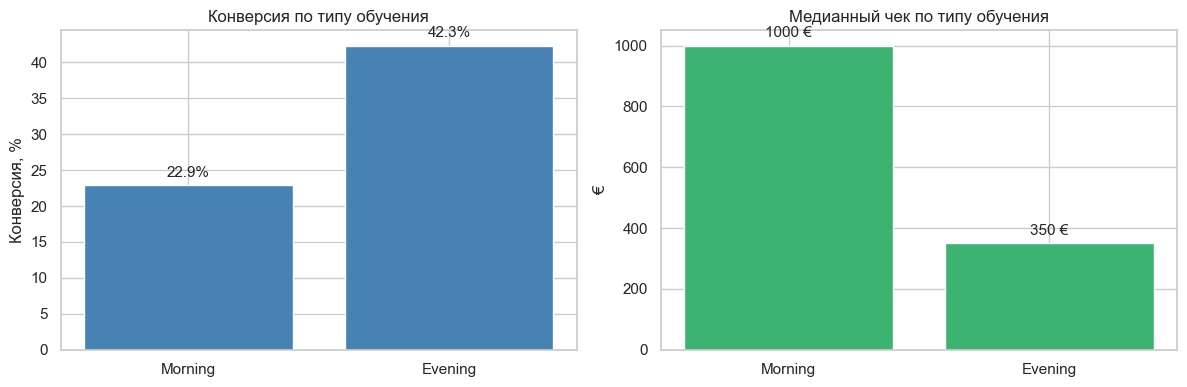

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Конверсия по типу обучения
bars0 = axes[0].bar(edu_stats['Education Type'], edu_stats['Конверсия %'],
                    color='steelblue')
axes[0].set_title('Конверсия по типу обучения')
axes[0].set_ylabel('Конверсия, %')
axes[0].bar_label(bars0, fmt='%.1f%%', padding=4)

# Медианный чек по типу обучения
bars1 = axes[1].bar(edu_stats['Education Type'], edu_stats['Медиана чека'],
                    color='mediumseagreen')
axes[1].set_title('Медианный чек по типу обучения')
axes[1].set_ylabel('€')
axes[1].bar_label(bars1, fmt='%.0f €', padding=4)

plt.tight_layout()
plt.savefig(PLOTS + 'education_type.png', dpi=100)
plt.show()

**Вывод (раздел 8.3):** `Education Type` заполнен у 3 299 сделок (15,3%), два формата. Утренний (Morning) — основной по объёму (2 895 сделок), конверсия 22,9%, медианный чек 1 000 €. Вечерний (Evening) — меньше по объёму (404), но конверсия почти вдвое выше (42,3%) при вдвое более низком чеке (350 €). Вероятная причина: вечерние группы — работающие люди с высокой мотивацией, выбирающие более короткие/дешёвые форматы. Это точка роста: вечерний формат конвертирует заметно лучше — стоит тестировать его расширение.

### 8.4 Причины потери сделок (Lost Reason)

In [35]:
# Lost Reason — ключ к пониманию, почему клиенты уходят
lost_deals = deals[deals['Stage'] == 'Lost']
lost_reason = lost_deals['Lost Reason'].value_counts()
n_lost_reasons = lost_deals['Lost Reason'].nunique()

print(f'Всего причин потери: {n_lost_reasons} уникальных')
print()
print('Причины потери сделок:')
print(lost_reason.to_string())


Всего причин потери: 21 уникальных

Причины потери сделок:
Lost Reason
Doesn't Answer                             4074
Changed Decision                           2122
Duplicate                                  1746
Non target                                 1736
Stopped Answering                          1556
Invalid number                             1460
Expensive                                   614
needs time to think                         606
Conditions are not suitable                 524
Inadequate                                  174
Gutstein refusal                            163
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Didn't leave an application                 131
Next stream                                 131
Thought for free                            110
Does not know how to use a computer          49
Went to Rivals                               47
The contract did 

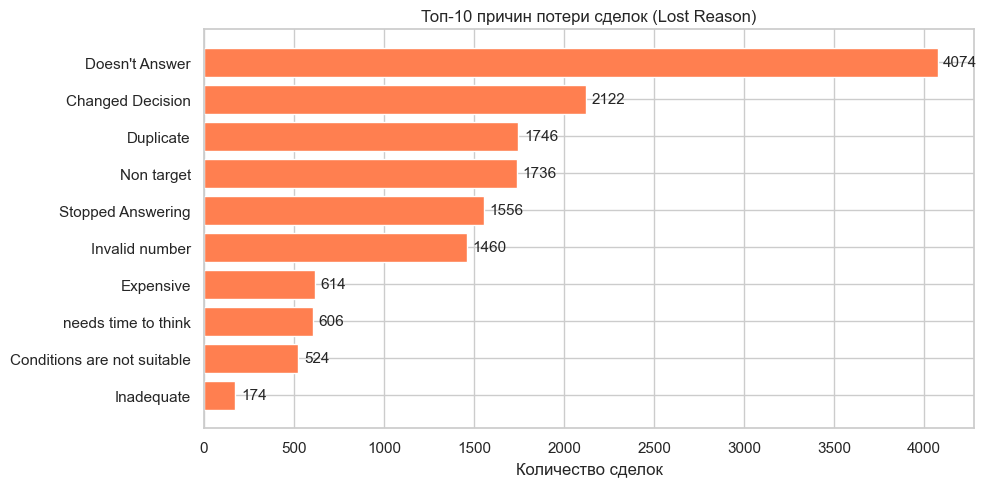

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

top_reasons = lost_reason.head(10)
bars = ax.barh(top_reasons.index[::-1], top_reasons.values[::-1], color='coral')
ax.set_title('Топ-10 причин потери сделок (Lost Reason)')
ax.set_xlabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig(PLOTS + 'lost_reasons.png', dpi=100)
plt.show()


In [37]:
# Доля каждой причины (топ-8)
total_lost = len(lost_deals)
print(f'Всего проигранных сделок: {total_lost}')
print()
print('Топ-8 причин потери сделок (%):')
for reason, count in lost_reason.head(8).items():
    print(f'  {reason}: {count} ({count/total_lost:.1%})')


Всего проигранных сделок: 15743

Топ-8 причин потери сделок (%):
  Doesn't Answer: 4074 (25.9%)
  Changed Decision: 2122 (13.5%)
  Duplicate: 1746 (11.1%)
  Non target: 1736 (11.0%)
  Stopped Answering: 1556 (9.9%)
  Invalid number: 1460 (9.3%)
  Expensive: 614 (3.9%)
  needs time to think: 606 (3.8%)


**Вывод (раздел 8.4):** Из 21 причины потери топ-5 охватывают более 60% всех потерь. «Doesn't Answer» (25,9%) — безоговорочный лидер: каждый четвёртый лид просто не берёт трубку. «Changed Decision» (13,5%) и дубликаты (11,1%) — на втором и третьем месте. «Non target» (11,0%) и «Stopped Answering» (9,9%) указывают на проблемы с качеством трафика и скоростью обработки. Цена («Expensive» — 3,9%) — не главная причина ухода, что снимает давление на ценообразование.

## 9. География: города

Смотрим географическое распределение лидов по городам.
Доп. пункт ТЗ — влияние уровня немецкого — рассмотрен в 9.2.


In [38]:
# Сделки по городам — только с заполненным городом
city_deals = deals[deals['City'].notna()].copy()
n_cities = deals['City'].nunique()

city_stats = (
    city_deals.groupby('City', observed=True)
    .apply(lambda x: pd.Series({
        'Лидов': len(x),
        'Оплат': (x['Stage'] == 'Payment Done').sum(),
        'Конверсия %': round((x['Stage'] == 'Payment Done').sum() / len(x) * 100, 2)
    }), include_groups=False)
    .reset_index()
    .sort_values('Лидов', ascending=False)
)

# Берём топ-15: в данных 875 уникальных городов, топ-15 = самые значимые рынки
top15_share = city_stats.head(15)['Лидов'].sum() / city_stats['Лидов'].sum() * 100
print(f'Всего уникальных городов: {n_cities}')
print(f'Топ-15 охватывают {top15_share:.1f}% всех лидов с городом')
print()
print('Топ-20 городов по числу лидов:')
print(city_stats.head(20).to_string(index=False))


Всего уникальных городов: 875
Топ-15 охватывают 29.5% всех лидов с городом

Топ-20 городов по числу лидов:
                  City  Лидов  Оплат  Конверсия %
                Berlin  182.0   78.0        42.86
               München   74.0   27.0        36.49
               Hamburg   62.0   22.0        35.48
              Nürnberg   45.0    9.0        20.00
               Leipzig   45.0   18.0        40.00
            Düsseldorf   33.0    7.0        21.21
               Dresden   28.0    9.0        32.14
             Frankfurt   27.0    7.0        25.93
              Dortmund   26.0    4.0        15.38
                  Köln   25.0    9.0        36.00
             Stuttgart   20.0    2.0        10.00
              Hannover   19.0    4.0        21.05
              Duisburg   19.0    5.0        26.32
                Bremen   17.0    5.0        29.41
             Karlsruhe   16.0    4.0        25.00
                 Essen   16.0    6.0        37.50
                Bochum   15.0    5.0       

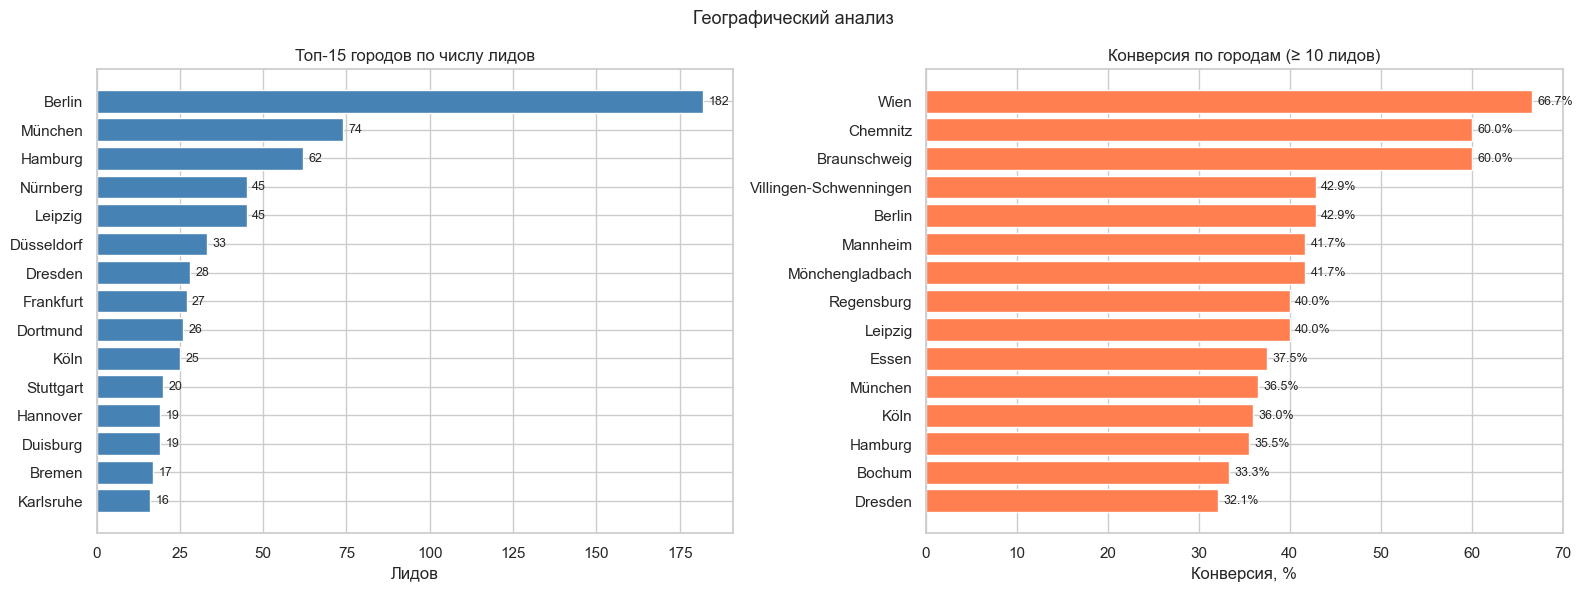

In [39]:
top_cities = city_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Лиды по городам
bars0 = axes[0].barh(top_cities['City'][::-1],
                     top_cities['Лидов'][::-1], color='steelblue')
axes[0].set_title('Топ-15 городов по числу лидов')
axes[0].set_xlabel('Лидов')
axes[0].bar_label(bars0, fmt='%d', padding=4, fontsize=9)

# Конверсия по городам (только с ≥ 10 лидами)
city_conv = city_stats[city_stats['Лидов'] >= 10].sort_values(
    'Конверсия %', ascending=False).head(15)
bars1 = axes[1].barh(city_conv['City'][::-1],
                     city_conv['Конверсия %'][::-1], color='coral')
axes[1].set_title('Конверсия по городам (≥ 10 лидов)')
axes[1].set_xlabel('Конверсия, %')
axes[1].bar_label(bars1, fmt='%.1f%%', padding=4, fontsize=9)

plt.suptitle('Географический анализ', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'geo_analysis.png', dpi=100)
plt.show()


**Вывод (раздел 9.1):** В данных 875 уникальных городов. Безусловный лидер по объёму — Берлин (182 лида). По конверсии картина иная: Берлин (42,86%), Leipzig (40,00%) и München (36,49%) показывают конверсию значительно выше средней (~4%). Это говорит о концентрации более «созревших» клиентов в крупных городах — приоритетная аудитория для гео-таргетинга.

### 9.2 Уровень немецкого

> **Поле исключено из анализа.** Установлено в этапе 1: `Level of Deutsch` — свободный текст менеджера, не стандартизирован. 215 «уникальных» значений из-за смешения кириллицы/латиницы (`B1`, `б1`, `В1`, `beginner`). Анализ невозможен без предварительной нормализации в CRM.

## 10. Сводные бизнес-выводы

In [40]:
# Итоговые числа для сводных выводов
peak = monthly_deals.loc[monthly_deals['Deals Count'].idxmax()]
best_conv_month = monthly_conv.loc[monthly_conv['Conversion %'].idxmax()]

best_campaign = (campaign_stats[campaign_stats['Лидов'] >= 20]
                 .nlargest(1, 'Конверсия %').iloc[0])

best_mgr = active_managers.nlargest(1, 'Конверсия %').iloc[0]

# «Find yourself in IT» — 4 лида, нерепрезентативно; берём лучший из основных (>=100 лидов)
best_prod = product_stats[product_stats['Сделок'] >= 100].nlargest(1, 'Конверсия %').iloc[0]

top_lost = lost_reason.index[0]
top_lost_pct = lost_reason.iloc[0] / total_lost

print('=== Ключевые числа (Этап 3) ===')
print(f'Пик лидов:          {peak["Month"].strftime("%b %Y")} — {peak["Deals Count"]} сделок')
print(f'Лучшая конверсия:   {best_conv_month["Month"].strftime("%b %Y")} — {best_conv_month["Conversion %"]}%')
print(f'Лучшая кампания:    {best_campaign["Campaign"]} ({best_campaign["Конверсия %"]}%)')
print(f'Лучший менеджер:    {best_mgr["Deal Owner Name"]} ({best_mgr["Конверсия %"]}%)')
print(f'Ведущий продукт:    {best_prod["Product"]} ({best_prod["Конверсия %"]}% конверсия)')
print(f'Гл. причина потери: «{top_lost}» ({top_lost_pct:.1%})')


=== Ключевые числа (Этап 3) ===
Пик лидов:          Apr 2024 — 3082 сделок
Лучшая конверсия:   Dec 2023 — 5.8%
Лучшая кампания:    Trigger_DE (13.16%)
Лучший менеджер:    Oliver Taylor (30.67%)
Ведущий продукт:    Web Developer (23.83% конверсия)
Гл. причина потери: «Doesn't Answer» (25.9%)


### Итоговые рекомендации

1. **Временные ряды:** Пик по объёму лидов — апрель 2024 (3 082 сделки), но конверсия в этом месяце упала до 2,47%. Лучшая конверсия — декабрь 2023 (5,80%). Масштабирование трафика без контроля качества разрушает воронку.
   → Ввести качественный фильтр при масштабировании кампаний.

2. **Кампании:** 154 кампании, лучшие по конверсии (≥ 20 лидов) — `Trigger_DE` (13,16%), `Live_DE` (11,11%), `brand_search_eng_DE` (8,93%).
   → Масштабировать брендовые и ретаргетинговые кампании; снизить бюджет широкого охвата.

3. **Источники:** Самый дорогой канал — Google Ads (57 799 €), но даёт лишь 9,6% качественных лидов. Partnership (16,2%), Facebook Ads (13,0%) и Webinar (12,9%) — лидеры по качеству.
   → Перераспределить бюджет в сторону вебинаров и Webinar-формата.

4. **Менеджеры:** Средняя конверсия — 3,95%, разброс — 6,34%. Oliver Taylor — 30,67% vs три менеджера с нулевой конверсией.
   → Провести аудит работы аутсайдеров, внедрить best practices лидера.

5. **Продукты:** Три основных продукта с одинаковой конверсией ~23% и чеком 1 000 €. Digital Marketing лидирует по объёму (474 оплаты).
   → Конкурентное преимущество — не в продукте, а в маркетинге и продажах.

6. **Потери:** «Doesn't Answer» — 25,9% всех потерь. Связка с SLA из этапа 2 критична.
   → Приоритет — первый контакт в течение 1 часа.

7. **География:** 875 городов. Топ-3 по конверсии — Берлин (42,86%), Leipzig (40,0%), München (36,49%).
   → Усилить гео-таргетинг на крупные немецкие города.

---
*Следующий этап: `04_unit_economics.ipynb` — CAC, ARPPU, юнит-экономика по продуктам и каналам.*
